In [50]:
import io
import os
import urllib
import zipfile
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import xlabel
from networkx.algorithms.bipartite.basic import color

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler


In [51]:
train_signals = os.listdir('/home/zhouliang/PycharmProjects/NAB_art/NAB/artificialWithAnomaly/artificialWithAnomaly')

In [52]:
df = pd.read_csv('/home/zhouliang/PycharmProjects/NAB_art/NAB/artificialWithAnomaly/artificialWithAnomaly/art_load_balancer_spikes.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  4032 non-null   object 
 1   value      4032 non-null   float64
dtypes: float64(1), object(1)
memory usage: 63.1+ KB
None


In [53]:
df.head(10)

,timestamp,value
0,2014-04-01 00:00:00,0.0
1,2014-04-01 00:05:00,0.0
2,2014-04-01 00:10:00,0.0
3,2014-04-01 00:15:00,0.0
4,2014-04-01 00:20:00,0.0
5,2014-04-01 00:25:00,0.0
6,2014-04-01 00:30:00,0.0
7,2014-04-01 00:35:00,0.0
8,2014-04-01 00:40:00,0.0
9,2014-04-01 00:45:00,0.0


In [54]:
df["timestamp"] = pd.to_datetime(df.timestamp)

df['timestamp'] = (df['timestamp'] - pd.Timestamp('1970-01-01')) // pd.Timedelta('1s')
df.head()

,timestamp,value
0,1396310400,0.0
1,1396310700,0.0
2,1396311000,0.0
3,1396311300,0.0
4,1396311600,0.0


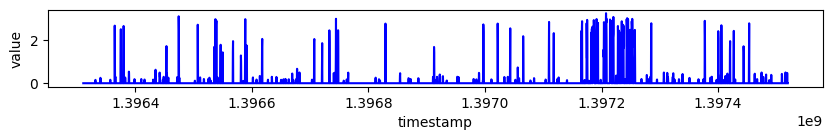

In [55]:
plt.figure(figsize = (10,1))
plt.plot(df.timestamp,df.value,color= 'blue')
plt.ylabel('value')
plt.xlabel('timestamp')
plt.show()

In [56]:
from orion.data import load_signal, load_anomalies
known_anomalies = load_anomalies('art_load_balancer_spikes')
known_anomalies

,start,end
0,1397123400,1397244000


In [57]:
def plot_func_with_anomaly(data, anomalies, test = False, predicted_anomalies = None,save_path = None):
    plt.figure(figsize= (20, 4))
    plt.plot(df['timestamp'], data['value'], label= "Time series Data")
    for i, row in  anomalies.iterrows():
        plt.axvspan(row['start'], row['end'], color = 'green', alpha = 0.3, label = 'Anomalous part')

    if(test==True):
        for i, row in predicted_anomalies.iterrows():
            plt.axvspan(row['start'], row['end'], color='red', alpha=0.3, label='predicted Anomalous Part')

    # Add legend and labels
    plt.legend()
    plt.xlabel('Timestamp')
    plt.ylabel('Value')
    plt.title('Time Series Plot with Anomalous Parts')
    if save_path:
        plt.savefig(save_path, format=save_path.split('.')[-1], bbox_inches='tight')
    # Show plot
    plt.show()


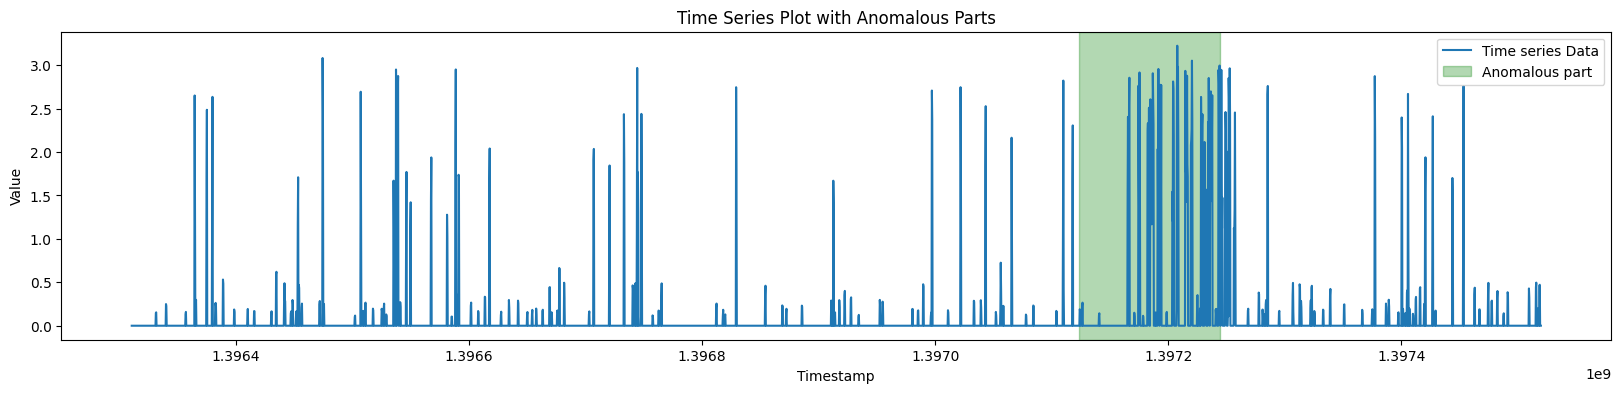

In [58]:
plot_func_with_anomaly(df, known_anomalies,save_path='art_load.svg')

In [59]:
def time_segments_aggregate(X, interval, time_column, method=['mean']):
    """Aggregate values over given time span.
    Args:
        X (ndarray or pandas.DataFrame):
            N-dimensional sequence of values.
        interval (int):
            Integer denoting time span to compute aggregation of.
        time_column (int):
            Column of X that contains time values.
        method (str or list):
            Optional. String describing aggregation method or list of strings describing multiple
            aggregation methods. If not given, `mean` is used.
    Returns:
        ndarray, ndarray:
            * Sequence of aggregated values, one column for each aggregation method.
            * Sequence of index values (first index of each aggregated segment).
    """
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)

    X = X.sort_values(time_column).set_index(time_column)

    if isinstance(method, str):
        method = [method]

    start_ts = X.index.values[0]
    max_ts = X.index.values[-1]

    values = list()
    index = list()
    while start_ts <= max_ts:
        end_ts = start_ts + interval
        subset = X.loc[start_ts:end_ts - 1]
        aggregated = [
            getattr(subset, agg)(skipna=True).values
            for agg in method
        ]
        values.append(np.concatenate(aggregated))
        index.append(start_ts)
        start_ts = end_ts

    return np.asarray(values), np.asarray(index)

X, index = time_segments_aggregate(df, interval=300, time_column='timestamp')

In [60]:
print(X.shape)
print(index.shape)

(4032, 1)
(4032,)


In [61]:
imp = SimpleImputer()
X_1 = imp.fit_transform(X)
#Todo:kalman filter
scaler = MinMaxScaler(feature_range=(-1, 1))
X_2 = scaler.fit_transform(X_1)
X = scaler.fit_transform(X)

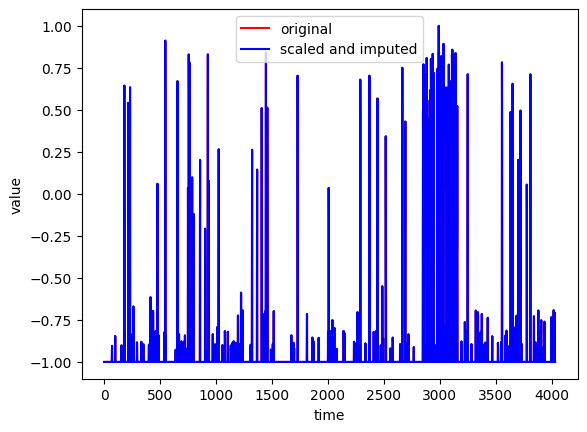

In [62]:
plt.plot(X[:,0],c='r',label='original')
plt.plot(X_2[:,0],c='b',label='scaled and imputed')
plt.legend()
plt.xlabel('time')
plt.ylabel('value')
plt.show()

In [63]:
print(X_2.shape)

(4032, 1)


In [64]:
def rolling_window_sequences(X, index, window_size, target_size, step_size, target_column,
                             drop=None, drop_windows=False):
    """Create rolling window sequences out of time series data.
    The function creates an array of input sequences and an array of target sequences by rolling
    over the input sequence with a specified window.
    Optionally, certain values can be dropped from the sequences.
    Args:
        X (ndarray):
            N-dimensional sequence to iterate over.
        index (ndarray):
            Array containing the index values of X.
        window_size (int):
            Length of the input sequences.
        target_size (int):
            Length of the target sequences.
        step_size (int):
            Indicating the number of steps to move the window forward each round.
        target_column (int):
            Indicating which column of X is the target.
        drop (ndarray or None or str or float or bool):
            Optional. Array of boolean values indicating which values of X are invalid, or value
            indicating which value should be dropped. If not given, `None` is used.
        drop_windows (bool):
            Optional. Indicates whether the dropping functionality should be enabled. If not
            given, `False` is used.
    Returns:
        ndarray, ndarray, ndarray, ndarray:
            * input sequences.
            * target sequences.
            * first index value of each input sequence.
            * first index value of each target sequence.
    """
    out_X = list()
    out_y = list()
    X_index = list()
    y_index = list()
    target = X[:, target_column]

    if drop_windows:
        if hasattr(drop, '__len__') and (not isinstance(drop, str)):
            if len(drop) != len(X):
                raise Exception('Arrays `drop` and `X` must be of the same length.')
        else:
            if isinstance(drop, float) and np.isnan(drop):
                drop = np.isnan(X)
            else:
                drop = X == drop

    start = 0
    max_start = len(X) - window_size - target_size + 1
    while start < max_start:
        end = start + window_size

        if drop_windows:
            drop_window = drop[start:end + target_size]
            to_drop = np.where(drop_window)[0]
            if to_drop.size:
                start += to_drop[-1] + 1
                continue

        out_X.append(X[start:end])
        out_y.append(target[end:end + target_size])
        X_index.append(index[start])
        y_index.append(index[end])
        start = start + step_size

    return np.asarray(out_X), np.asarray(out_y), np.asarray(X_index), np.asarray(y_index)

#Todo: 调参
X, y, X_index, y_index = rolling_window_sequences(X_2, index,
                                                  window_size=130,
                                                  target_size=1,
                                                  step_size=1,
                                                  target_column=0)

In [65]:
print("Training data input shape: {}".format(X.shape))
print("Training data index shape: {}".format(X_index.shape))
print("Training y shape: {}".format(y.shape))
print("Training y index shape: {}".format(y_index.shape))

Training data input shape: (3902, 130, 1)
Training data index shape: (3902,)
Training y shape: (3902, 1)
Training y index shape: (3902,)


In [66]:
def plot_rows(X,window_size):
      idx=np.arange(0,X.shape[1])
      plt.figure(figsize=(6,2))
      plt.plot(idx,X[0,:],color='blue')
      plt.title('window 0')
      plt.show()

      plt.figure(figsize=(6,2))
      plt.plot(idx,X[20,:],color='red')
      plt.title('window 5')
      plt.show()

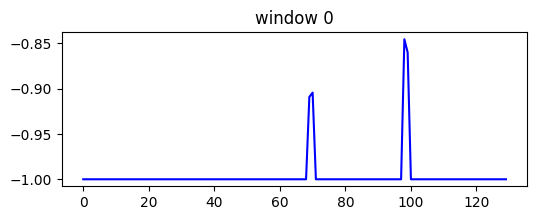

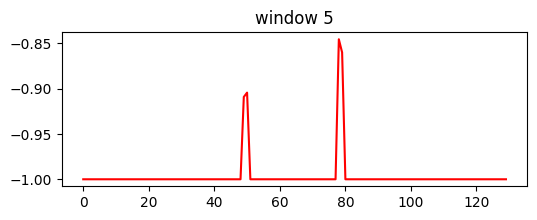

In [67]:
plot_rows(X,100)

In [68]:
import time
from mlstars import load_primitive


#Todo:调参
tadgan = load_primitive('orion.primitives.tadgan.TadGAN',arguments={"X": X, "y":X, "epochs":40, "batch_size": 32,'detailed_losses':True})

start_time = time.time()
tadgan.fit()

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Elapsed time: {elapsed_time} seconds")

Epoch: 1/40, Losses: {'cx_loss': array([-13.0568, -47.3876,  31.5893,   0.2741]), 'cz_loss': array([-6.556 ,  0.3193, -7.5898,  0.0715]), 'eg_loss': array([-20.2407, -32.8995,  10.6206,   0.2038])}
Epoch: 2/40, Losses: {'cx_loss': array([   3.1982, -120.0106,  120.4837,    0.2725]), 'cz_loss': array([-6.3742,  0.8184, -7.5553,  0.0363]), 'eg_loss': array([-1.112251e+02, -1.203489e+02,  8.272600e+00,  8.510000e-02])}
Epoch: 3/40, Losses: {'cx_loss': array([-3.905000e-01, -1.059435e+02,  1.049726e+02,  5.800000e-02]), 'cz_loss': array([11.4949,  0.7583,  9.3511,  0.1386]), 'eg_loss': array([-1.089565e+02, -1.039768e+02, -5.833100e+00,  8.530000e-02])}
Epoch: 4/40, Losses: {'cx_loss': array([-9.11800e-01, -7.60931e+01,  7.47044e+01,  4.77000e-02]), 'cz_loss': array([-62.8051,   1.045 , -64.9936,   0.1144]), 'eg_loss': array([ -0.9371, -74.2838,  72.5272,   0.082 ])}
Epoch: 5/40, Losses: {'cx_loss': array([-1.14140e+00, -5.86987e+01,  5.70286e+01,  5.29000e-02]), 'cz_loss': array([-4.6401,

In [69]:
X_hat, critic = tadgan.produce(X=X,y=X)


122/122 [==============================] - 1s 4ms/step


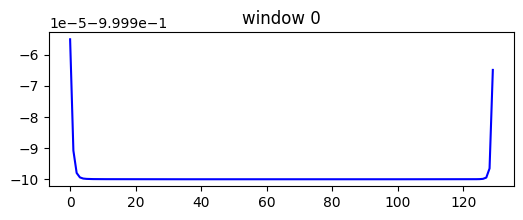

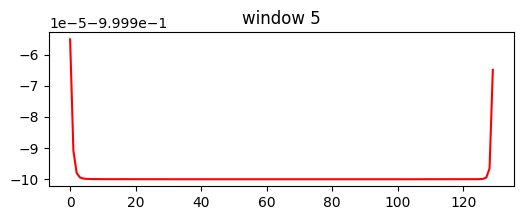

In [70]:
plot_rows(X_hat,100)


In [71]:
def unroll_ts(y_hat):
    predictions = list()
    pred_length = y_hat.shape[1]
    num_errors = y_hat.shape[1] + (y_hat.shape[0] - 1)

    for i in range(num_errors):
            intermediate = []

            for j in range(max(0, i - num_errors + pred_length), min(i + 1, pred_length)):
                intermediate.append(y_hat[i - j, j])

            if intermediate:
                predictions.append(np.median(np.asarray(intermediate)))

    return np.asarray(predictions[pred_length-1:])

In [72]:
def plot_rws(X, window=20, k=5):
    shift = 20
    X = X[window:]
    t = range(len(X))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


    num_figs = int(np.ceil(k / 5)) + 1
    fig = plt.figure(figsize=(15, num_figs * 2))

    j = 0
    ax = fig.add_subplot(num_figs, 5, j+1)
    idx = t[j: window + j]
    ax.plot(idx, X[j], lw=2, color=colors[j])
    plt.title("window %d" % j, size=16)
    plt.ylim([-1, 1])

    j = 1
    ax = fig.add_subplot(num_figs, 5, j+1)
    idx = t[j: window + j]
    ax.plot(idx, X[j], lw=2, color=colors[j])
    ax.set_yticklabels([])
    plt.title("window %d" % j, size=16)
    plt.ylim([-1, 1])

    for i in range(2, k):
        j = i * shift
        idx = t[j: window + j]

        ax = fig.add_subplot(num_figs, 5, i+1)
        ax.plot(idx, X[j], lw=2, color=colors[i+1])
        ax.set_yticklabels([])
        plt.title("window %d" % j, size=16)
        plt.ylim([-1, 1])

    plt.tight_layout()
    plt.show()

In [73]:
# flatten the predicted windows
y_hat = unroll_ts(X_hat)

print(y_hat.shape)
print(y.shape)

(3902,)
(3902, 1)


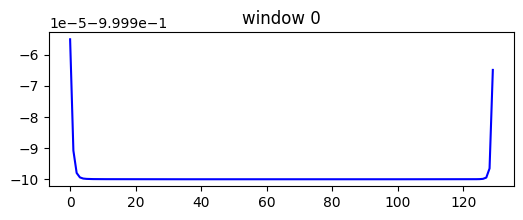

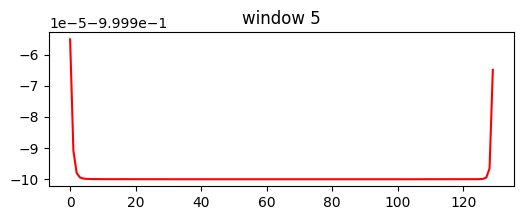

In [74]:
plot_rows(X_hat,100)

In [75]:
def plot_ts(X, labels=None):
    fig = plt.figure(figsize=(30, 6))
    ax = fig.add_subplot(111)

    if not isinstance(X, list):
        X = [X]

    for x in X:
        t = range(len(x))
        plt.plot(t, x)

    plt.title('art data', size=34)
    plt.ylabel('value', size=30)
    plt.xlabel('Time', size=30)
    plt.xticks(size=26)
    plt.yticks(size=26)
    plt.xlim([t[0], t[-1]])

    if labels:
        plt.legend(labels=labels, loc=1, prop={'size': 26})

    plt.show()

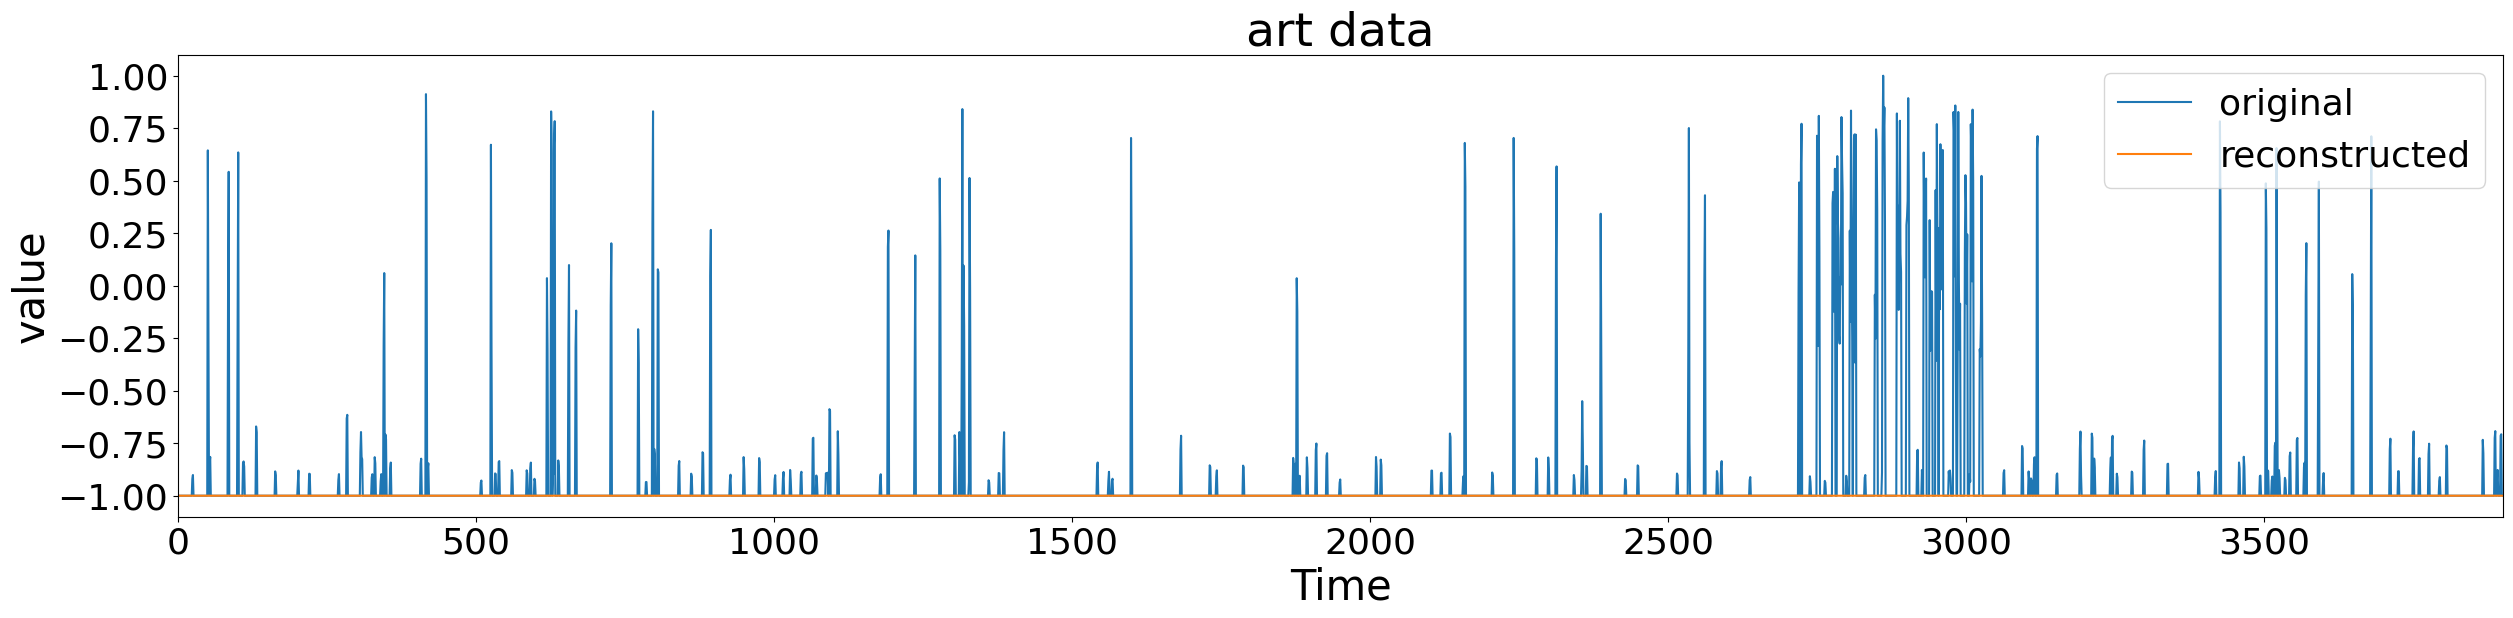

In [76]:
plot_ts([y, y_hat], labels=['original', 'reconstructed'])

In [77]:
print(y.shape)

(3902, 1)


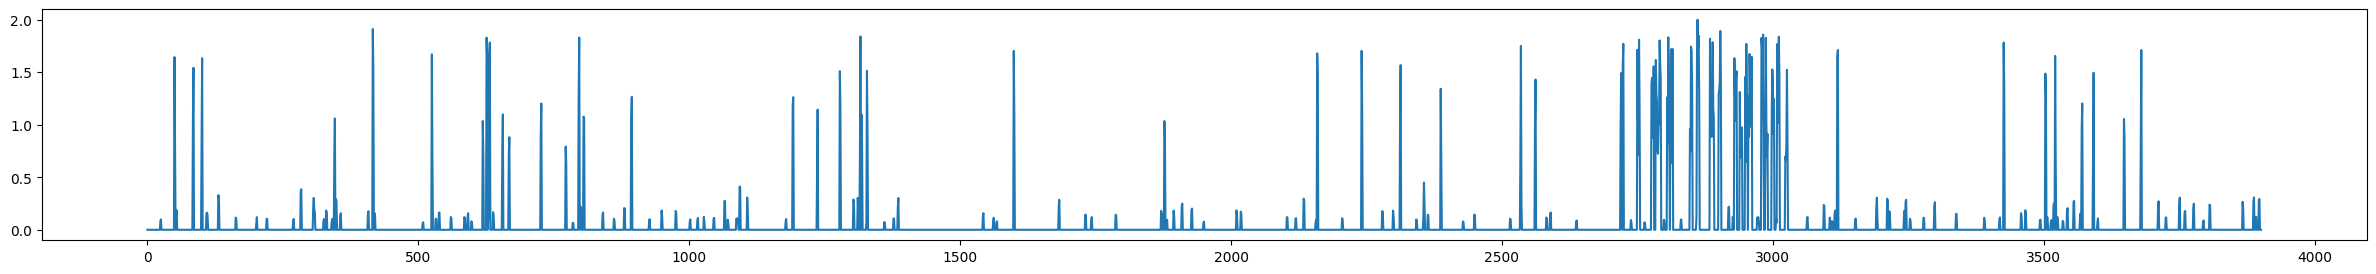

In [78]:
# pair-wise error calculation
error = np.zeros(shape=y.shape)
length = y.shape[0]
for i in range(length):
    error[i] = abs(y_hat[i] - y[i])

# visualize the error curve
fig = plt.figure(figsize=(30, 3))
plt.plot(error)
plt.show()

In [79]:
print(len(df['timestamp']))

4032


In [80]:
from orion.primitives.tadgan import score_anomalies
#Todo: error type
error, true_index, true, pred = score_anomalies(X, X_hat, critic, X_index, rec_error_type="dtw", comb="mult")
pred = np.array(pred).mean(axis=2)


In [81]:
print(len(error))

4031


In [82]:
print(len(df['timestamp']))

4032


In [83]:
import matplotlib.gridspec as gridspec
def plot_error(X):
    plt.figure(figsize = (30, 6))
    gs1 = gridspec.GridSpec(3, 1)
    gs1.update(wspace=0.025, hspace=0.05)

    i = 0
    for x in X:
        if len(x) == 2:
            ax1 = plt.subplot(gs1[i:i+2])
            for line in x:
                t = range(len(line))
                ax1.plot(t, line)
            i+=1
        else:
            ax1 = plt.subplot(gs1[i])
            t = range(len(line))
            ax1.plot(t, x, color='tab:red')

        i+=1
        plt.xlim(t[0], t[-1])
        plt.yticks(size=22)
        plt.axis('on')
        ax1.set_xticklabels([])
    plt.savefig('art_load_reconstruct.svg', format='svg', bbox_inches='tight')
    plt.show()

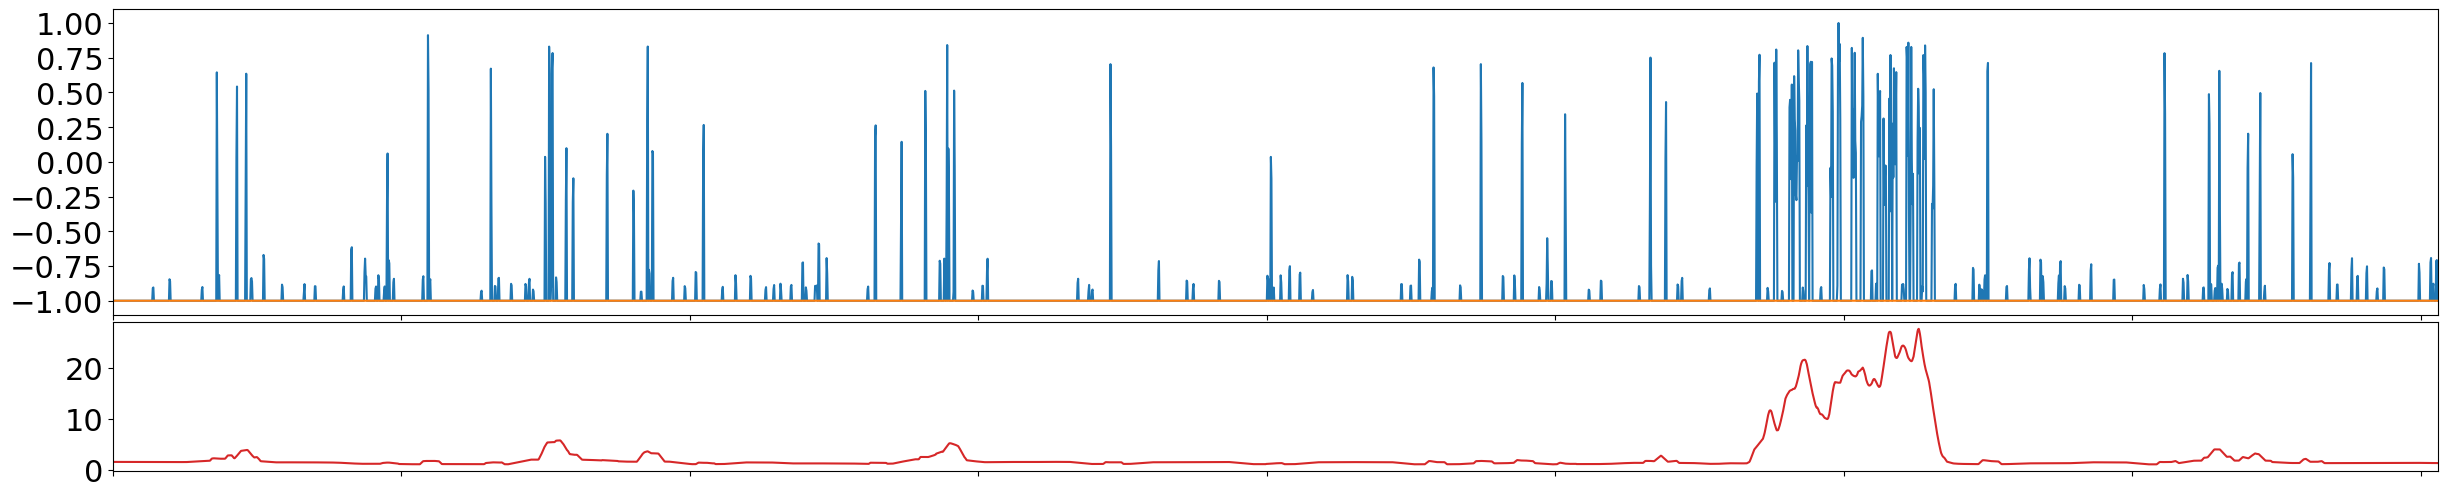

In [84]:
# visualize the error curve
plot_error([[true, pred], error])

In [85]:
print(len(df['timestamp']))

4032


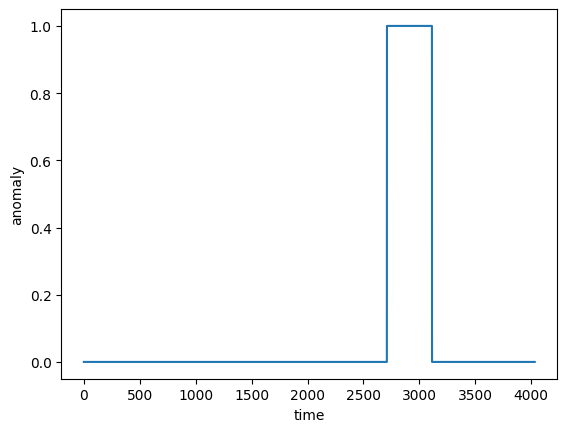

In [86]:
## Run this cell to reproduce the plot correctly
start = known_anomalies['start']
end = known_anomalies['end']
df_new = df.copy()
df_new['label'] = 0

for i in range(len(df_new)):
    for j in range(len(start)):
        if (df_new.loc[i, 'timestamp'] >= start[j] and df_new.loc[i, 'timestamp'] <= end[j]):
            df_new.loc[i, 'label'] = 1
            break

plt.plot(df_new['label'])
plt.xlabel('time')
plt.ylabel('anomaly')
plt.show()

In [87]:
ground_truth=df_new['label']
print(len(df_new['label']))

4032


In [88]:
print(len(ground_truth),len(error))

4032 4031


prob_anomaly:---
 [0.01792179 0.01791813 0.01791481 ... 0.00945261 0.009367   0.00924719]
shape:  (4031,)


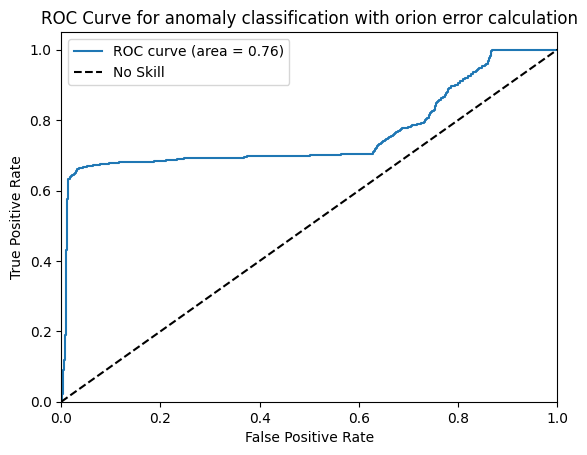

In [89]:
ground_truth_last=ground_truth[:-1]
ground_truth_first=ground_truth[1:]

error_min=np.min(error)
error_max=np.max(error)
error_range=error_max-error_min

prob_anomaly = (error-error_min)/error_range
print('prob_anomaly:---\n',prob_anomaly)
print('shape: ',prob_anomaly.shape)

from sklearn.metrics import roc_curve, auc
# with the last row discarded
fpr, tpr, thresholds = roc_curve(ground_truth_last, prob_anomaly)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for anomaly classification with orion error calculation')
plt.legend()
plt.show()

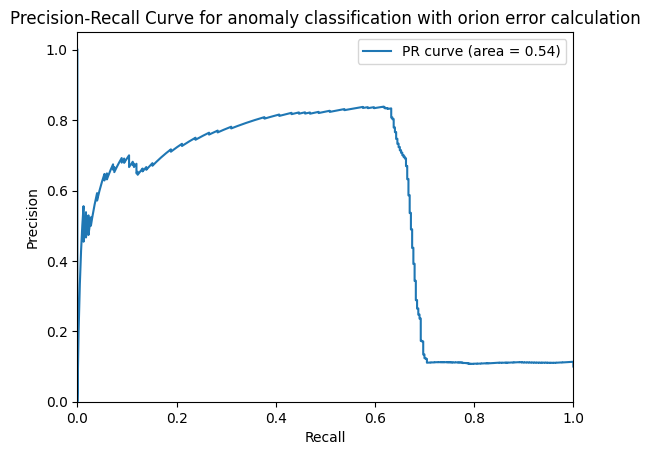

In [90]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, pr_thresholds = precision_recall_curve(ground_truth_last, prob_anomaly)
average_precision = average_precision_score(ground_truth_last, prob_anomaly)

# Plot the PR curve
plt.figure()
plt.plot(recall, precision, label='PR curve (area = %0.2f)' % average_precision)
#plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for anomaly classification with orion error calculation')
plt.legend()
plt.show()

In [91]:
from sklearn.metrics import average_precision_score
avg_precision_score=average_precision_score(ground_truth_last,prob_anomaly)
avg_precision_score

0.5443959798454898

In [92]:
sensitivity = np.array(tpr)

# Calculate specificity (true negative rate)
specificity = 1 - np.array(fpr)

# Calculate Youden's J statistic
youden_j = sensitivity + specificity - 1

# Find the index of the maximum Youden's J statistic
best_threshold_index = np.argmax(youden_j)

# Get the corresponding threshold
best_threshold = thresholds[best_threshold_index]

print("Threshold for best performance (Youden's J):", best_threshold)
error_threshold_best=error_range*best_threshold+error_min
print(error_threshold_best)

Threshold for best performance (Youden's J): 0.11469213457697365
4.0775344537981155


In [93]:

intervals = list()

i = 0
max_start = len(error)
while i < max_start:
    j = i
    start = index[i]
    while i < len(error) and error[i] > error_threshold_best: #tuning it
        i += 1

    end = index[i]
    if start != end:
        intervals.append((start, end, np.mean(error[j: i+1])))

    i += 1

intervals

[(1396534500, 1396546200, 5.207678213357232),
 (1396743300, 1396750800, 4.77907937614432),
 (1397164500, 1397260800, 16.545554915055476)]

In [94]:
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

def convert_date(timelist):
    converted = list()
    for x in timelist:
        converted.append(datetime.fromtimestamp(x))
    return converted

def convert_date_single(x):
    return datetime.fromtimestamp(x)

def plot(dfs, anomalies=[]):
    """ Line plot for time series.

    This function plots time series and highlights anomalous regions.
    The first anomaly in anomalies is considered the ground truth.

    Args:
        dfs (list or `pd.DataFrame`): List of time series in `pd.DataFrame`.
            Or a single dataframe. All dataframes must have the same shape.
        anomalies (list): List of anomalies in tuple format.
    """
    if isinstance(dfs, pd.DataFrame):
        dfs = [dfs]

    if not isinstance(anomalies, list):
        anomalies = [anomalies]

    df = dfs[0]
    time = convert_date(df['timestamp'])
    months = mdates.MonthLocator()  # every month
    days = mdates.DayLocator() # every day

    month_fmt = mdates.DateFormatter('%b')

    fig = plt.figure(figsize=(30, 6))
    ax = fig.add_subplot(111)

    for df in dfs:
        plt.plot(time, df['value'])

    colors = ['red'] + ['green'] * (len(anomalies) - 1)
    for i, anomaly in enumerate(anomalies):
        if not isinstance(anomaly, list):
            anomaly = list(anomaly[['start', 'end']].itertuples(index=False))

        for _, anom in enumerate(anomaly):
            t1 = convert_date_single(anom[0])
            t2 = convert_date_single(anom[1])
            plt.axvspan(t1, t2, color=colors[i], alpha=0.2)

    plt.title('art_jumpsdown data', size=34)
    plt.ylabel('value', size=30)
    plt.xlabel('Time', size=30)
    plt.xticks(size=26)
    plt.yticks(size=26)
    plt.xlim([time[0], time[-1]])

    # format xticks
    ax.xaxis.set_major_locator(months)
    ax.xaxis.set_major_formatter(month_fmt)
    ax.xaxis.set_minor_locator(days)

    # format yticks
    ylabels = ['{:,.0f}'.format(x) + 'K' for x in ax.get_yticks()/1000]
    ax.set_yticklabels(ylabels)

    plt.show()

In [95]:
anomalies = pd.DataFrame(intervals, columns=['start', 'end', 'score'])


In [96]:
def plot_func_with_anomaly(data,anomalies,test=False,predicted_anomalies=None):
    plt.figure(figsize=(40, 6))

    # Plot the time series data
    plt.plot(data['timestamp'], data['value'], label='Time Series Data',linewidth=2.5)

    # Shade the anomalous parts

    for i, row in anomalies.iterrows():
        plt.axvspan(row['start'], row['end'], color='green', alpha=0.3, label='Anomalous Part')

    if(test==True):
        for i, row in predicted_anomalies.iterrows():
            plt.axvspan(row['start'], row['end'], color='red', alpha=0.3, label='predicted Anomalous Part')

    # Add legend and labels

    plt.xlabel('Timestamp')
    plt.ylabel('Value')
    plt.title('Time Series Plot with Anomalous Parts')
    plt.savefig('art_load_anomaly.svg', format='svg', bbox_inches='tight')
    # Show plot
    plt.show()

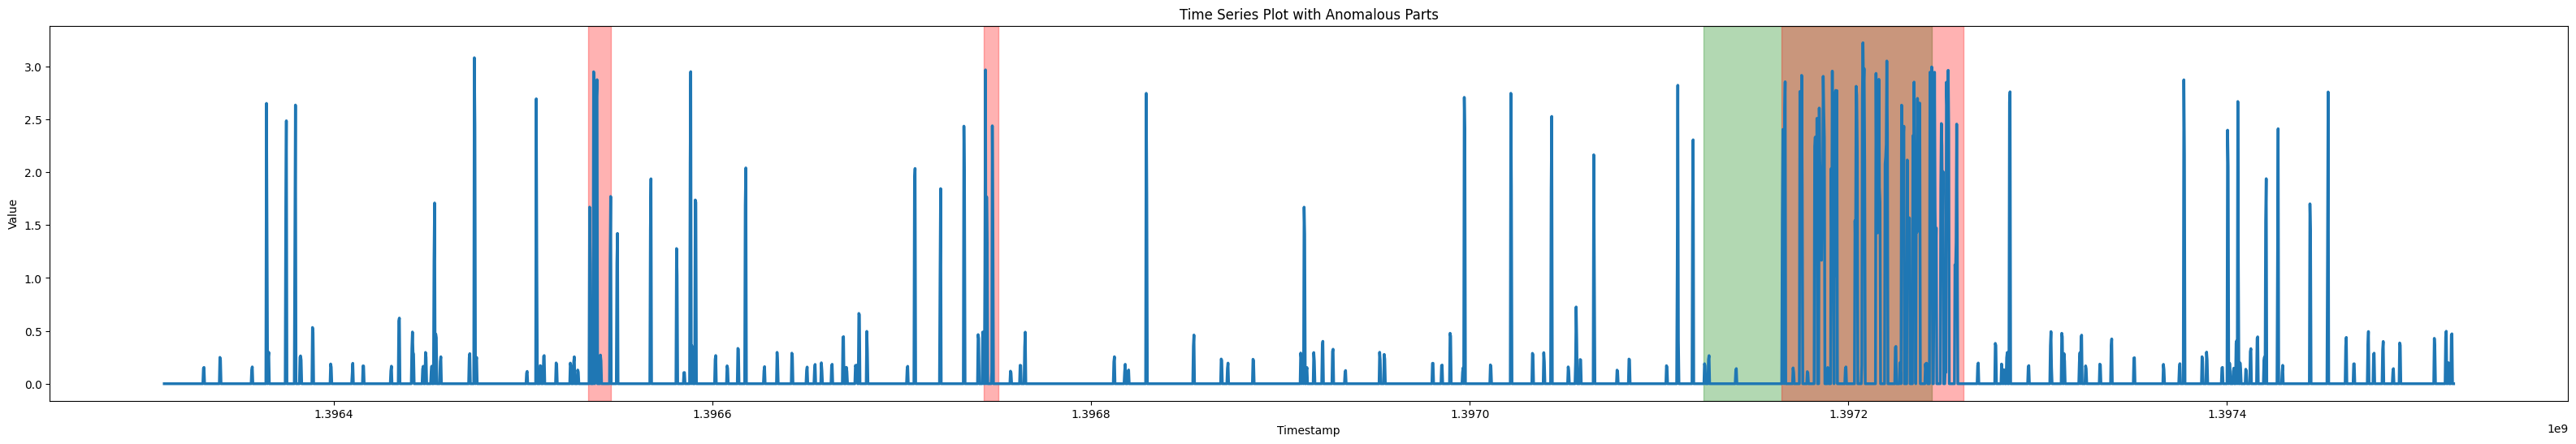

In [97]:

plot_func_with_anomaly(df,known_anomalies,test=True,predicted_anomalies=anomalies)

In [98]:
from orion.evaluation.contextual import contextual_accuracy, contextual_f1_score



accuracy = contextual_accuracy(known_anomalies, anomalies, start=start, end=end)
f1_score = contextual_f1_score(known_anomalies, anomalies, start=start, end=end)

print("Accuracy score = {:0.3f}".format(accuracy))
print("F1 score = {:0.3f}".format(f1_score))

from orion.evaluation.contextual import contextual_confusion_matrix

confusion_matrix = contextual_confusion_matrix(known_anomalies, anomalies, start=start, end=end)

tn=confusion_matrix[0]
fp=confusion_matrix[1]
fn=confusion_matrix[2]
tp=confusion_matrix[3]

precision=tp/(tp+fp)
recall=tp/(tp+fn)
print("precision: ",precision)
print("recall: ",recall)

Accuracy score = 0.922
F1 score = 0.673
precision:  0.6883024683341559
recall:  0.6592068059137155
